In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, recall_score

In [2]:
df = pd.read_csv("../data/raw/Telecom-Customer-Churn.csv")
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [12]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df['TotalCharges'].fillna(0,inplace=True)
df.isnull().sum()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14176\2361711735.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0,inplace=True)


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [22]:
df.drop('customerID', axis=1, inplace=True)

<Axes: xlabel='Churn'>

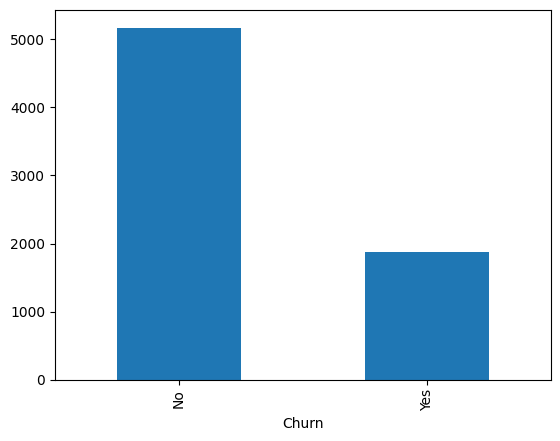

In [9]:
df['Churn'].value_counts(normalize=True)
df['Churn'].value_counts().plot(kind='bar')

<Axes: xlabel='Churn', ylabel='tenure'>

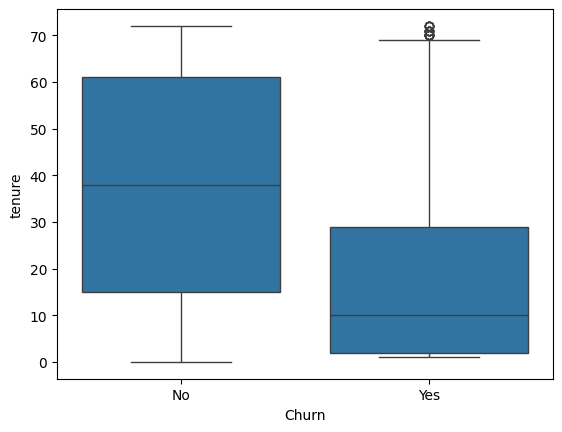

In [10]:
sns.boxplot(x='Churn', y='tenure', data=df)

<Axes: xlabel='Churn', ylabel='TotalCharges'>

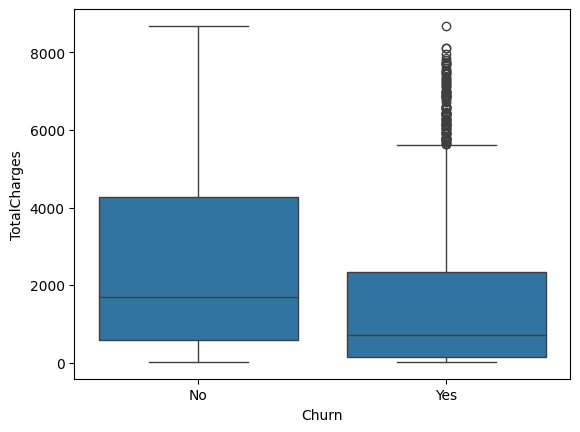

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
sns.boxplot(x='Churn', y='TotalCharges', data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

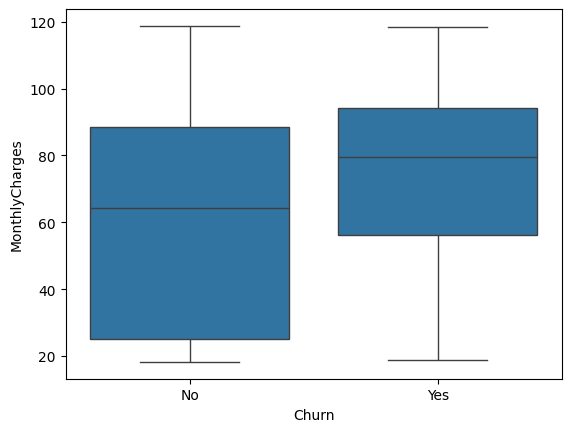

In [12]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

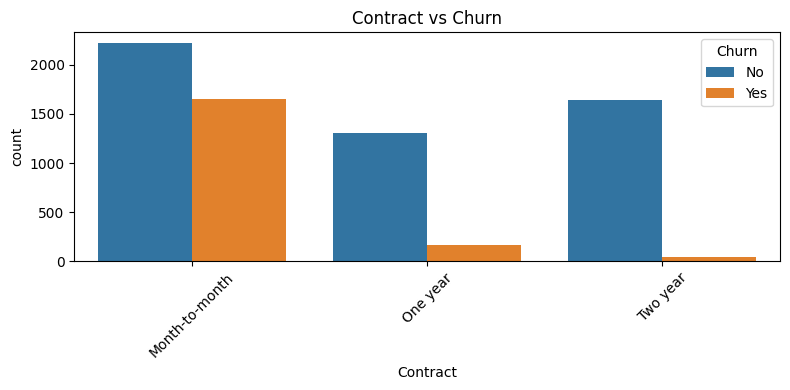

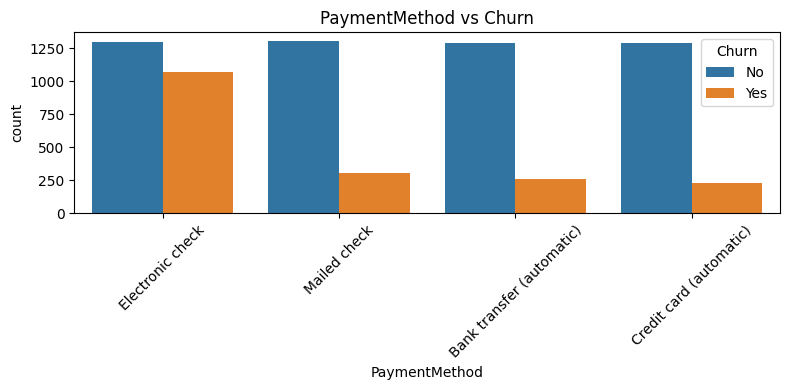

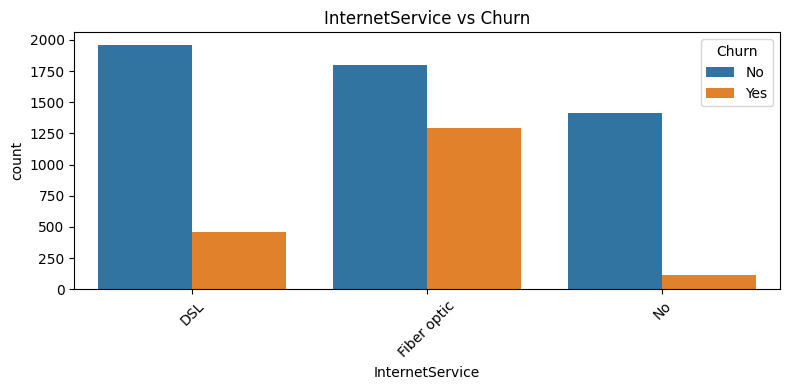

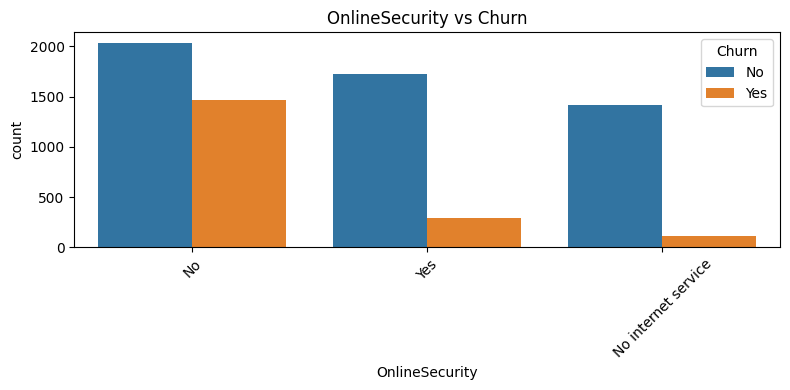

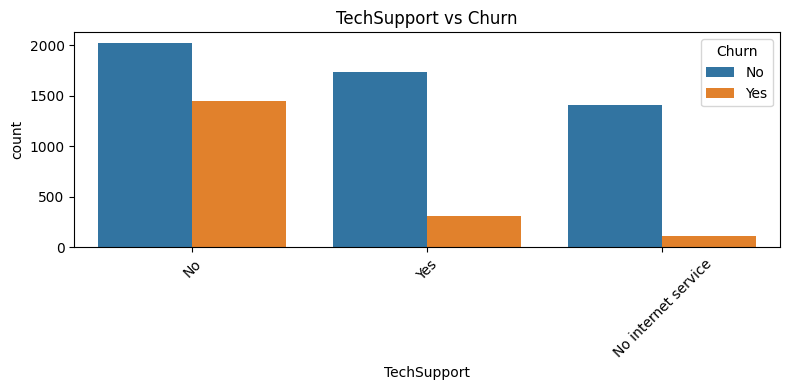

In [13]:
cat_cols = ['Contract', 'PaymentMethod', 'InternetService',
            'OnlineSecurity', 'TechSupport']

for col in cat_cols:
    fig = plt.figure(figsize=(8,4))  
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [21]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df = pd.read_csv('C:\\Users\\ASUS\\Downloads\\archive\\Telco-Customer-Churn.csv')  
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop('customerID', axis=1, inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12172\150989220.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [9]:
df = pd.get_dummies(df, drop_first=True) 
df.rename(columns={'Churn_Yes': 'Churn'}, inplace=True)  

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n=== BASELINE MODELS ===")
models_base = {
    'LR': LogisticRegression(max_iter=1000, random_state=42),
    'RF': RandomForestClassifier(random_state=42),
    'XG': xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

for name, model in models_base.items():
    model.fit(X_train_scaled, y_train) 
    y_pred = model.predict(X_test_scaled) 
    recall = recall_score(y_test, y_pred)
    print(f"{name} Baseline Recall: {recall:.1%}")


=== BASELINE MODELS ===
LR Baseline Recall: 56.7%
RF Baseline Recall: 49.2%
XG Baseline Recall: 53.5%


In [15]:
print("\n=== IMPROVED MODELS  ===")


X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)
X_train_sm_scaled = scaler.fit_transform(X_train_sm) 

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

models_imp = {
    'LR': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'RF': RandomForestClassifier(n_estimators=800, class_weight='balanced', random_state=42, n_jobs=-1),
    'XG': xgb.XGBClassifier(scale_pos_weight=scale_pos, n_estimators=500, max_depth=6,
                            learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                            random_state=42, eval_metric='auc')
}

threshold = 0.30

for name, model in models_imp.items():
    model.fit(X_train_sm_scaled, y_train_sm)
    
    proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (proba >= threshold).astype(int)
    recall = recall_score(y_test, y_pred)
    print(f"{name} Improved Recall: {recall:.1%}")
    
    if name == 'XG':  
        print(f"\n--- {name} Improved Full Report ---")
        print(classification_report(y_test, y_pred))


=== IMPROVED MODELS  ===


C:\Users\ASUS\anaconda3\envs\churnenv\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


LR Improved Recall: 97.6%
RF Improved Recall: 85.3%
XG Improved Recall: 85.3%

--- XG Improved Full Report ---
              precision    recall  f1-score   support

       False       0.91      0.53      0.67      1035
        True       0.39      0.85      0.54       374

    accuracy                           0.61      1409
   macro avg       0.65      0.69      0.60      1409
weighted avg       0.77      0.61      0.63      1409



In [17]:
print(sorted([k for k in globals().keys() if k.startswith(('X_', 'y_'))]))

['X_test', 'X_train', 'y_test', 'y_train']


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import FixedThresholdClassifier 
import joblib
import os


xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc'
)


tuned_model = FixedThresholdClassifier(
    estimator=xgb_model, 
    threshold=0.30, 
    response_method="predict_proba"
)


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', tuned_model)
])

pipeline.fit(X_train_sm, y_train_sm)

os.makedirs("models", exist_ok=True)
joblib.dump(pipeline, "models/churn_pipeline.joblib")
joblib.dump(X.columns.tolist(), "models/feature_columns.joblib")

print("Pipeline with 0.30 threshold saved successfully!")

Pipeline with 0.30 threshold saved successfully!


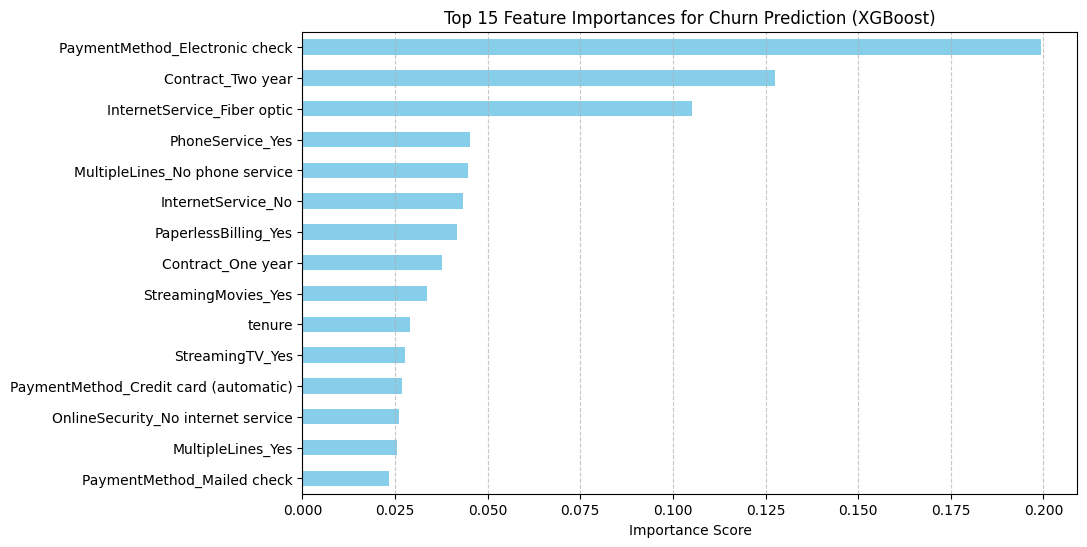

In [19]:
threshold_model = pipeline.named_steps['classifier']

best_xgb = threshold_model.estimator_


feature_importances = pd.Series(
    best_xgb.feature_importances_, 
    index=X.columns
).sort_values(ascending=False)


plt.figure(figsize=(10, 6))
feature_importances.head(15).plot(kind='barh', color='skyblue')
plt.title("Top 15 Feature Importances for Churn Prediction (XGBoost)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()